In [1]:
import os
import time
import joblib
import numpy as np
import polars as pl
import psutil

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# OPTUNA
import optuna

# XGBOOST
from xgboost import XGBClassifier

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 2. PREPARACION DATASET
# ==========================================

TARGET_COL = "label"

df_encoded = pl.read_csv("../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv")

# Separación de características (X) y variable objetivo (y)
feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
X = df_encoded.select(feature_columns)
y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
X_np = X.to_numpy()

display(X.head())

indices = np.arange(X_np.shape[0])

train_full_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_np,
)

train_idx, val_idx = train_test_split(
    train_full_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_np[train_full_idx],
)

X_full_train_np = X_np[train_full_idx]
X_test_np = X_np[test_idx]
y_full_train = y_np[train_full_idx]
y_test_np = y_np[test_idx]

X_train_np = X_np[train_idx]
X_val_np = X_np[val_idx]
y_train_np = y_np[train_idx]
y_val_np = y_np[val_idx]

print(f"Entrenamiento: {len(X_train_np):,} muestras")
print(f"Validación:    {len(X_val_np):,} muestras")
print(f"Test:          {len(X_test_np):,} muestras")
print(f"Clases en test: {np.unique(y_test_np)}")
print(f"Total muestras: {len(X_np):,}")

id.orig_p,id.resp_p,proto_icmp,proto_tcp,proto_udp,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,conn_state_OTH,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH,conn_state_SHR
i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
51524,23,0,1,0,2.999051,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
56305,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
41101,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
60905,23,0,1,0,2.998796,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
44301,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


Entrenamiento: 745,504 muestras
Validación:    186,376 muestras
Test:          232,971 muestras
Clases en test: [0 1]
Total muestras: 1,164,851


In [3]:
def objective(trial):
    # 1. Sugerir hiperparámetros
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 12)
    
    # 2. Configurar el Validador Cruzado (3 Folds Estratificados)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    f1_scores = []
    latencies = []

    # 3. Bucle de Cross-Validation
    # ATENCIÓN: Usamos los nombres exactos de los arrays generados en el split anterior
    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train):
        # Dividir datos del fold
        X_train_cv, X_val_cv = X_full_train_np[train_idx], X_full_train_np[val_idx]
        y_train_cv, y_val_cv = y_full_train[train_idx], y_full_train[val_idx]

        # 3) Modelo XGBoost
        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,

            learning_rate=0.1, # Tasa de aprendizaje fijada

            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            
            # Aceleración del hardware
            tree_method="hist",
            device="cuda",
        )

        # Entrenamiento del fold
        model.fit(X_train_cv, y_train_cv)

        # Inferencia en CPU para que Pareto refleje el escenario de despliegue
        model.set_params(device="cpu")

        # Predicción y métrica de eficacia (F1)
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average='binary'))

        # Medición de eficiencia (Latencia) en este fold
        subset = min(20000, len(X_val_cv)) 
        X_lat = X_val_cv[:subset]

        # Warm-up rápido para estabilizar la inferencia
        _ = model.predict(X_lat[:min(500, len(X_lat))])

        rep_lat = []
        for _ in range(3): 
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    # 4. Promediar resultados de los 3 folds
    avg_f1 = np.mean(f1_scores)
    avg_lat = np.mean(latencies)
    std_f1 = np.std(f1_scores) 

    # Guardamos atributos extra para el análisis posterior
    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat

# --- EJECUCIÓN ---

study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="iot23_xgboost_optimization_cv"
)

print("🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...")
print("Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).")

# Puedes reducir n_trials si ves que tarda demasiado por el tamaño del dataset
study.optimize(objective, n_trials=50)

# ==========================================
# EXTRACCIÓN DE DATOS A POLARS
# ==========================================

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_binary": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t in study.best_trials 
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("xgboost_iot23_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'xgboost_iot23_trials_results_cv.csv'")
print(df_results.sort("f1_binary", descending=True).head())

[I 2026-04-20 19:22:13,761] A new study created in memory with name: iot23_xgboost_optimization_cv


🚀 Iniciando barrido multiobjetivo con 3-Fold Cross-Validation para IoT-23...
Nota: Cada trial ahora entrena 3 modelos. Evaluando F1 Binario (Benigno vs Malicioso).


[I 2026-04-20 19:22:15,355] Trial 0 finished with values: [0.9992281833255673, 5.683576669576319e-05] and parameters: {'n_estimators': 50, 'max_depth': 6}.
[I 2026-04-20 19:22:18,802] Trial 1 finished with values: [0.99923901346419, 0.00028510077225089647] and parameters: {'n_estimators': 400, 'max_depth': 12}.
[I 2026-04-20 19:22:20,103] Trial 2 finished with values: [0.9992227642726436, 9.927066669964309e-05] and parameters: {'n_estimators': 400, 'max_depth': 2}.
[I 2026-04-20 19:22:21,037] Trial 3 finished with values: [0.9992272707869629, 7.200034999388865e-05] and parameters: {'n_estimators': 50, 'max_depth': 12}.
[I 2026-04-20 19:22:23,186] Trial 4 finished with values: [0.9992372120185955, 0.00017658198891391902] and parameters: {'n_estimators': 500, 'max_depth': 5}.
[I 2026-04-20 19:22:26,509] Trial 5 finished with values: [0.99923901346419, 0.0002666902499590328] and parameters: {'n_estimators': 450, 'max_depth': 10}.
[I 2026-04-20 19:22:28,199] Trial 6 finished with values: [


✅ Resultados robustos guardados en 'xgboost_iot23_trials_results_cv.csv'
shape: (5, 6)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┐
│ n_estimators ┆ max_depth ┆ f1_binary ┆ f1_std   ┆ latency_ms ┆ is_pareto │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       │
│ i64          ┆ i64       ┆ f64       ┆ f64      ┆ f64        ┆ bool      │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╡
│ 400          ┆ 11        ┆ 0.999243  ┆ 0.000089 ┆ 0.000318   ┆ false     │
│ 450          ┆ 11        ┆ 0.999243  ┆ 0.000089 ┆ 0.000292   ┆ true      │
│ 200          ┆ 9         ┆ 0.999243  ┆ 0.000089 ┆ 0.00013    ┆ true      │
│ 300          ┆ 11        ┆ 0.999242  ┆ 0.00009  ┆ 0.000207   ┆ false     │
│ 350          ┆ 8         ┆ 0.999242  ┆ 0.00009  ┆ 0.000179   ┆ false     │
└──────────────┴───────────┴───────────┴──────────┴────────────┴───────────┘


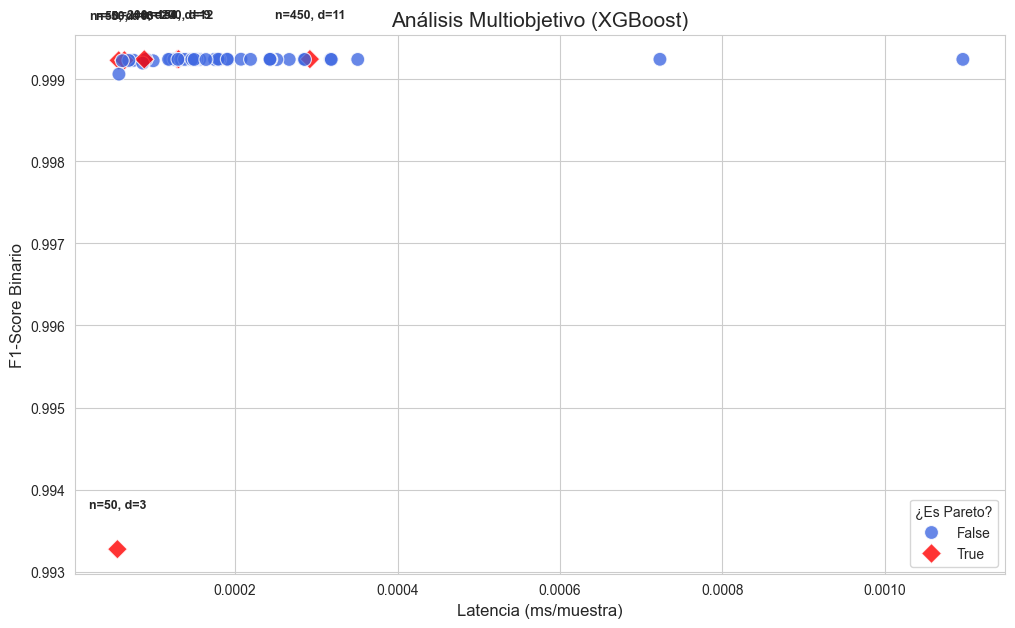

In [4]:
# ==========================================
# GRAFICA PARETO (Polars + NumPy Edition)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

df = pl.read_csv("xgboost_iot23_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_binary"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_binary"] + 0.0005,
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9, fontweight='bold', ha='center'
    )

plt.title("Análisis Multiobjetivo (XGBoost)", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Binario", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

/tmp/ipykernel_39513/2486073535.py:38: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


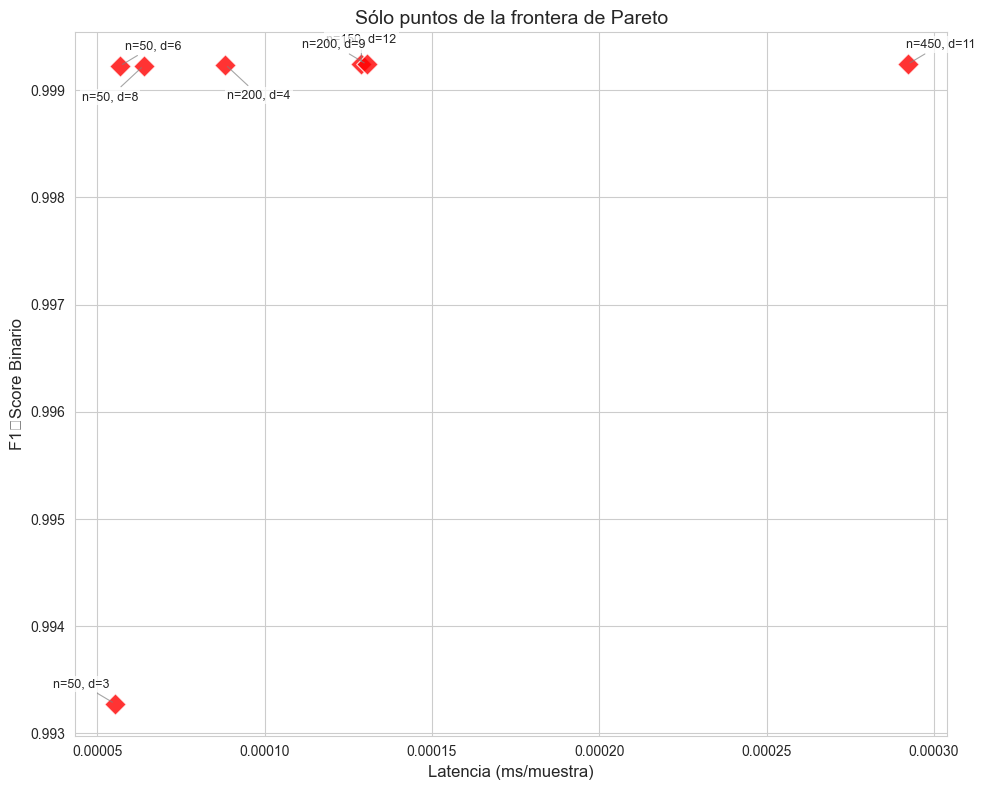

n_estimators,max_depth,f1_binary,f1_std,latency_ms,is_pareto
i64,i64,f64,f64,f64,bool
50,3,0.993277,0.000142,0.000055,true
50,6,0.999228,0.000097,0.000057,true
50,8,0.999229,0.000099,0.000064,true
200,4,0.99924,0.000092,0.000088,true
150,12,0.999242,0.00009,0.000129,true
200,9,0.999243,0.000089,0.00013,true
450,11,0.999243,0.000089,0.000292,true


In [ ]:
# AHORA SOLO REPRESENTAMOS LOS MODELOS DE LA FRONTERA DE PARETO

df = pl.read_csv("xgboost_iot23_trials_results_cv.csv")
pareto_df = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_binary"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.8,
    ax=ax
)

offsets = [(-24, 10), (24, 10), (-24, -18), (24, -18), (0, 14)]
for i, row in enumerate(pareto_df.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_binary"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="center",
        va="bottom" if dy >= 0 else "top",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8, alpha=0.7)
    )

plt.title("Sólo puntos de la frontera de Pareto", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Binario", fontsize=12)
plt.tight_layout()
plt.show()

display(pareto_df)

In [7]:
# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS)
# ==========================================

candidatos = [
    {"n": 50, "d": 8, "nombre": "Candidato 1"},
    {"n": 50, "d": 6, "nombre": "Candidato 2"},
    {"n": 200, "d": 4, "nombre": "Candidato 3"},
    {"n": 200, "d": 9, "nombre": "Candidato 4"},
    {"n": 150, "d": 12, "nombre": "Candidato 5"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---\n")

# Convertimos y_train/y_test a 0/1 para XGB
y_full_train01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01    = ((y_test_np + 1) // 2).astype(np.int8)

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")

    model = XGBClassifier(
            n_estimators=c["n"],
            max_depth=c["d"],
            learning_rate=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,

            # Entrenamiento acelerado en GPU
            tree_method="hist",
            device="cuda"
    )

    model.fit(X_full_train_np, y_full_train01)

    model.set_params(device="cpu")  # Inferencia en CPU para replicar el escenario real de despliegue
    # Warm-up
    _ = model.predict(X_test_np[:min(1000, len(X_test_np))])

    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_np)
    t1 = time.perf_counter()

    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000
    f1_test = f1_score(y_test_np01, y_pred01, average="binary")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_estimators": c["n"],
        "max_depth": c["d"],
        "F1_Binary_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*60)
print("              TABLA COMPARATIVA FINAL (XGBoost)")
print("="*60)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---

Probando: Candidato 1 (n=50, d=8)...
Probando: Candidato 2 (n=50, d=6)...
Probando: Candidato 3 (n=200, d=4)...
Probando: Candidato 4 (n=200, d=9)...
Probando: Candidato 5 (n=150, d=12)...

              TABLA COMPARATIVA FINAL (XGBoost)
shape: (5, 6)
┌─────────────┬──────────────┬───────────┬────────────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_estimators ┆ max_depth ┆ F1_Binary_Test ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---          ┆ ---       ┆ ---            ┆ ---           ┆ ---         │
│ str         ┆ i64          ┆ i64       ┆ f64            ┆ f64           ┆ f64         │
╞═════════════╪══════════════╪═══════════╪════════════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 50           ┆ 8         ┆ 0.999114       ┆ 0.998948      ┆ 0.000028    │
│ Candidato 2 ┆ 50           ┆ 6         ┆ 0.999122       ┆ 0.998957      ┆ 0.000027    │
│ Candidato 3 ┆ 200          ┆ 4         ┆ 0.999122       ┆ 0